# Utilize custom constraints

This tutorial extends the demonstration of solving second-order problems directly.

For background information on what's presented below, see:

  > Bosch, Nathanael, Filip Tronarp, and Philipp Hennig.
    "Pick-and-mix information operators for probabilistic ODE solvers."
    International Conference on Artificial Intelligence and Statistics.
    PMLR, 2022.


In [1]:
"""Demonstrate how to implement custom information operators."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import ivpsolve, probdiffeq

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)

Define the problem.

In [2]:
@jax.jit
def vf_1st(y, /, *, t):
    """Evaluate the harmonic oscillator dynamics."""
    u, du = jnp.split(y, 2)
    return jnp.concatenate([du, vf_2nd(u, du, t=t)])


def hamiltonian_1st(y):
    """Evaluate the Hamiltonian of the harmonic oscillator."""
    u, du = jnp.split(y, 2)
    return hamiltonian_2nd(u, du)


@jax.jit
def vf_2nd(y, dy, *, t):  # noqa: ARG001
    """Evaluate the harmonic oscillator as a 2nd-order problem."""
    return -y


def hamiltonian_2nd(u, du):
    """Evaluate the Hamiltonian of the harmonic oscillator."""
    kinetic = 0.5 * jnp.dot(du, du)
    potential = 0.5 * jnp.dot(u, u)
    return kinetic + potential


t0, t1 = 0.0, 100.0  # reeeeally long time-integration
u0_1st = jnp.array([1.0, 0.0, 0.0, 1.0])
save_at = jnp.linspace(t0, t1, endpoint=True, num=500)

A good solution conserves the Hamiltonian.

In [3]:
H0 = hamiltonian_1st(u0_1st)

Set up the first-order solver (for illustration).

In [4]:
tcoeffs = [u0_1st]
init, ssm = probdiffeq.ssm_taylor(tcoeffs, diffuse_derivatives=2)
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)
ts1 = probdiffeq.constraint_ode_ts1(vf_1st, ssm=ssm)
strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)
solver_1st = probdiffeq.solver_mle(
    strategy=strategy, prior=iwp, constraint=ts1, ssm=ssm
)
error = probdiffeq.error_state_std(constraint=ts1, prior=iwp, ssm=ssm)
solve = ivpsolve.solve_adaptive_save_at(solver=solver_1st, error=error)

Solve at relatively poor tolerances to make the Hamiltonian drift more obvious.

In [5]:
sol_1 = jax.jit(solve)(init, save_at=save_at, atol=1e-2, rtol=1e-2)
ham_1 = jax.vmap(hamiltonian_1st)(sol_1.u.mean[0])

The harmonic oscillator calls for a custom information operator because
we know: (i) the ODE is second order; (ii) the Hamiltonian should be conserved.

In [6]:
def root(u, du, ddu, /, *, t):
    """Evaluate a custom root for the harmonic oscillator."""
    deriv = ddu - vf_2nd(u, du, t=t)
    hamil = hamiltonian_2nd(u, du) - H0
    return [deriv, hamil]  # any PyTree goes

Set up the custom-root solver.

We don't use high orders because high-order initialisation
of custom-information-operator solvers is an open problem.
But for low-order solvers, custom roots work well.

In [7]:
u0, du0 = jnp.split(u0_1st, 2)
tcoeffs = [u0, du0]
init, ssm = probdiffeq.ssm_taylor(tcoeffs, diffuse_derivatives=1)
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)

Use this constraint function for custom roots:

In [8]:
ts1 = probdiffeq.constraint_root_ts1(root, ssm=ssm)
strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)
solver_2nd = probdiffeq.solver_mle(
    strategy=strategy, prior=iwp, constraint=ts1, ssm=ssm
)

Custom roots with residual-based error estimates
require norming-then-scaling
(instead of scaling-then-norming, which is the default),
because scaling-then-norming assumes that the root pytree
has the same structure as the target pytree.

In [9]:
error = probdiffeq.error_state_std(constraint=ts1, prior=iwp, ssm=ssm)
solve = ivpsolve.solve_adaptive_save_at(solver=solver_2nd, error=error)

sol_2 = jax.jit(solve)(init, save_at=save_at, atol=1e-2, rtol=1e-2)
ham_2 = jax.vmap(hamiltonian_2nd)(sol_2.u.mean[0], sol_2.u.mean[1])

Plot both solutions.
See how much better the custom root solver preserves the Hamiltonian?

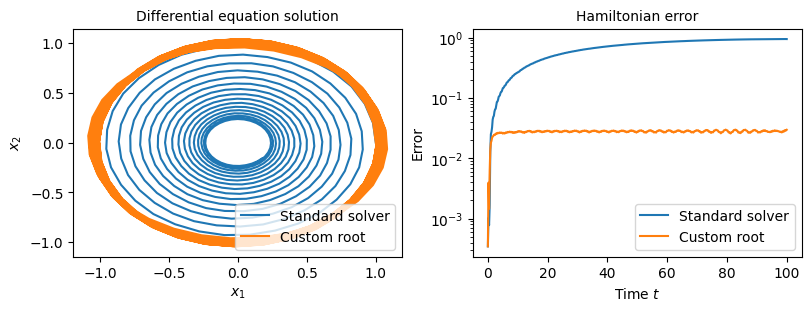

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 3), constrained_layout=True)

ax[0].set_title("Differential equation solution", fontsize="medium")
ax[0].plot(sol_1.u.mean[0][:, 0], sol_1.u.mean[0][:, 1], "-", label="Standard solver")
ax[0].plot(sol_2.u.mean[0][:, 0], sol_2.u.mean[0][:, 1], "-", label="Custom root")
ax[0].legend()
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

eps = jnp.sqrt(jnp.finfo(sol_2.t).eps)
ax[1].set_title("Hamiltonian error", fontsize="medium")
ax[1].semilogy(sol_1.t, eps + jnp.abs(ham_1 - H0), label="Standard solver")
ax[1].semilogy(sol_2.t, eps + jnp.abs(ham_2 - H0), label="Custom root")
ax[1].set_xlabel("Time $t$")
ax[1].set_ylabel("Error")
ax[1].legend()
# ax[1].set_ylim((eps, 10))
plt.show()